# Data Exploration — MultiXC-QM9

This notebook explores the MultiXC-QM9 dataset in preparation for implementing
the Δ-ML approach from Ramakrishnan et al. (2015).

**Goal:** Understand the dataset structure, check data quality, and compute
ΔE = E_target - E_baseline for each molecule, which is the training target
for the Δ-ML model.

**Dataset:** Nandi, Vegge & Bhowmik (2023). MultiXC-QM9.
DOI: 10.1038/s41597-023-02690-2

**Data path:** `~/Documents/mit/datasets/multiXC-QM9/molecules_qm9.csv`

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load the main dataset containing molecular energies at 76 DFT functionals
# and 3 basis sets (SZ, DZP, TZP) for ~133k QM9 molecules
df = pd.read_csv('/Users/jonathanamara/Documents/mit/datasets/multiXC-QM9/molecules_qm9.csv') # df = data frame

# Shape: (n_molecules, n_features) — expect ~133k rows, ~232 columns
print(df.shape)

# Column names: molecule identifiers + energies named as FUNCTIONAL_BASISSET
print(df.columns.tolist())

(133055, 232)
['KCIS-MODIFIED_SZ', 'KCIS-ORIGINAL_SZ', 'PKZB_SZ', 'VS98_SZ', 'LDA(VWN)_SZ', 'PW91_SZ', 'BLYP_SZ', 'BP_SZ', 'PBE_SZ', 'RPBE_SZ', 'REVPBE_SZ', 'OLYP_SZ', 'FT97_SZ', 'BLAP3_SZ', 'HCTH/93_SZ', 'HCTH/120_SZ', 'HCTH/147_SZ', 'HCTH/407_SZ', 'BMTAU1_SZ', 'BOP_SZ', 'PKZBX-KCISCOR_SZ', 'VS98-X(XC)_SZ', 'VS98-X-ONLY_SZ', 'BECKE00_SZ', 'BECKE00X(XC)_SZ', 'BECKE00-X-ONLY_SZ', 'BECKE88X+BR89C_SZ', 'OLAP3_SZ', 'TPSS_SZ', 'MPBE_SZ', 'OPBE_SZ', 'OPERDEW_SZ', 'MPBEKCIS_SZ', 'MPW_SZ', 'TAU-HCTH_SZ', 'XLYP_SZ', 'KT1_SZ', 'KT2_SZ', 'M06-L_SZ', 'BLYP-D_SZ', 'BP86-D_SZ', 'PBE-D_SZ', 'TPSS-D_SZ', 'B97-D_SZ', 'REVTPSS_SZ', 'PBESOL_SZ', 'RGE2_SZ', 'SSB-D_SZ', 'MVS_SZ', 'MVSX_SZ', 'T-MGGA_SZ', 'TPSSH_SZ', 'B3LYP(VWN5)_SZ', 'O3LYP(VWN5)_SZ', 'KMLYP(VWN5)_SZ', 'PBE0_SZ', 'B3LYP*(VWN5)_SZ', 'BHANDH_SZ', 'BHANDHLYP_SZ', 'B97_SZ', 'B97-1_SZ', 'B97-2_SZ', 'MPBE0KCIS_SZ', 'MPBE1KCIS_SZ', 'B1LYP(VWN5)_SZ', 'B1PW91(VWN5)_SZ', 'MPW1PW_SZ', 'MPW1K_SZ', 'TAU-HCTH-HYBRID_SZ', 'X3LYP(VWN5)_SZ', 'OPBE0_SZ', 'M0

## First Look at the Data

`df.head()` shows the first 5 rows — used to visually inspect the data structure
before any analysis.

**What we expect to see:**
- Energy columns: numeric, negative values in Hartree
- `index`: molecule ID (integer, starts at 1)
- `smiles`: molecular structure as a text string
- `chemformula`: chemical formula

Note: pandas hides middle columns with `...` when there are too many to display.
This is normal — all 228 energy columns are there.

In [3]:
# df.head() shows the first 5 rows of the dataframe
# used to get a quick visual overview of the data structure
# here we can see: energy columns (numeric, in Hartree),
# index (molecule ID), smiles (molecular structure as string),
# chemformula (chemical formula)
df.head()

,KCIS-MODIFIED_SZ,KCIS-ORIGINAL_SZ,PKZB_SZ,VS98_SZ,LDA(VWN)_SZ,PW91_SZ,BLYP_SZ,BP_SZ,PBE_SZ,RPBE_SZ,...,OPBE0_TZP,M05_TZP,M05-2X_TZP,M06_TZP,M06-2X_TZP,B3LYP-D_TZP,GFNXTB,index,smiles,chemformula
0,-22.255476,-22.149955,-22.522395,-22.113949,-24.720830,-22.216716,-21.917224,-22.633217,-22.210579,-21.746071,...,-19.218846,-19.268411,-20.158556,-19.171700,-19.987828,-19.169475,-21.979934,1,[H]C([H])([H])[H],CH4
1,-13.432236,-13.295914,-13.498102,-12.936122,-15.420338,-13.396731,-13.271763,-13.685120,-13.388004,-12.983106,...,-12.471078,-12.762201,-12.764569,-12.708668,-12.694483,-12.901951,-17.405808,2,[H]N([H])[H],H3N
2,-9.648970,-9.605053,-9.733063,-9.533739,-11.005073,-9.699852,-9.541240,-9.873553,-9.655585,-9.389576,...,-11.390619,-11.515124,-12.637161,-11.560591,-12.538535,-11.227973,-14.033122,3,[H]O[H],H2O
3,-19.980634,-20.041293,-20.184447,-20.007219,-22.462543,-20.202519,-19.635248,-20.207609,-20.258750,-19.675576,...,-19.476077,-19.510770,-21.532072,-19.512685,-21.246587,-19.281763,-22.665365,4,[H]C#C[H],C2H2
4,-13.945840,-13.935402,-13.985081,-13.499069,-15.716800,-14.053964,-13.685391,-13.961498,-14.125807,-13.656508,...,-14.088747,-14.431799,-15.452642,-14.410027,-15.292001,-14.393565,-19.345571,5,[H]C#N,CHN


## Dataset Overview

The MultiXC-QM9 dataset contains **133,055 molecules** from the QM9 database
(molecules with charge separation excluded).

**Structure:**
- Each row = one molecule
- `index`: original QM9 molecule ID
- `smiles`: molecular structure as a SMILES string (e.g. `[H]O[H]` = water)
- `chemformula`: chemical formula (e.g. `H2O`)
- 228 energy columns: named `FUNCTIONAL_BASISSET` (e.g. `PBE_SZ`, `B3LYP_TZP`)
- `GFNXTB`: semiempirical XTB energy (cheapest method, different energy reference)

**Energy units:** Hartree (atomic units). All values negative — molecules are
more stable than their separated atoms.

**Key observation:** Same functional at different basis sets (e.g. `PBE_SZ` vs
`PBE_TZP`) gives systematically different energies. This systematic difference
is exactly what Δ-ML learns to correct.

**No missing values** — all 133,055 molecules have energies for all methods.

In [4]:
# .describe() gives summary statistics for every numeric column
# useful for spotting outliers, missing values, and unexpected ranges
# we select just a few columns to keep the output readable
df[['PBE_SZ', 'PBE_TZP', 'GFNXTB', 'index']].describe()

,PBE_SZ,PBE_TZP,GFNXTB,index
count,133055.000000,133055.000000,133055.000000,133055.000000
mean,-93.404169,-83.127188,-108.031924,66864.298546
std,15.011107,11.039344,11.971017,38596.784362
min,-146.389880,-122.138581,-149.135446,1.000000
25%,-103.419458,-90.239677,-116.095363,33494.500000
50%,-93.499581,-83.310418,-108.679619,66894.000000
75%,-83.702506,-76.060291,-101.018137,100275.500000
max,-9.655585,-10.370616,-14.033122,133885.000000


## Computing ΔE (Delta Energy)

The core idea of Δ-ML: instead of predicting absolute energies directly,
we train a model to predict the **correction** between a cheap and an
accurate method:

ΔE = E_target - E_baseline

The model then learns: given a molecular representation, predict ΔE.
At inference time: E_predicted = E_cheap + ML(ΔE)

**Why this works:** The correction ΔE is a smoother, simpler function
than the total energy — it requires less training data to learn accurately.

**Here:** baseline = `PBE_SZ` (cheap), target = `PBE_TZP` (more accurate)
`df['column']` selects a single column as a pandas Series (1D array).
Subtracting two Series of the same length works elementwise —
molecule by molecule.

In [7]:
# Compute ΔE between two theory levels for every molecule
# ΔE = E_target - E_baseline
# target: PBE_TZP (larger basis, more accurate)
# baseline: PBE_SZ (smaller basis, cheaper)
delta_E = df['PBE_TZP'] - df['PBE_SZ']
print(delta_E.shape)

(133055,)


## ΔE Distribution — First Look

`delta_E.describe()` shows summary statistics for the computed corrections.

**Key observations:**
- Mean ΔE ≈ +10.28 Hartree — PBE_TZP is on average higher than PBE_SZ
- std ≈ 4.23 Hartree — significant variation across molecules
- Some negative values (min = -4.1) — not all molecules follow the same trend

**Note on sign:** Naively we expect TZP < SZ (variational principle — larger
basis always lowers total energy). The positive mean here is because these are
**atomization energies**, not total energies. The atomic reference energies
also change with basis set, which can flip the sign of the difference.
This needs careful handling before training any model.

In [6]:
print(delta_E.describe())

count    133055.000000
mean         10.276981
std           4.230596
min          -4.102724
25%           7.404213
50%          10.343808
75%          13.199810
max          24.280850
dtype: float64


## Visualizing the ΔE Distribution

A histogram bins values along x and counts how many fall in each bin.
Standard first plot for any distribution.

**Observations:**
- Roughly bell-shaped, centered around +10 Hartree
- Slight right skew — larger molecules have bigger basis set corrections
- Range: -5 to +25 Hartree (enormous in chemical terms, ~6000 kcal/mol mean)
- Small negative tail — physically valid cases where TZP < SZ

**Implication for Δ-ML:** The model must learn corrections over a wide range.
In practice we will convert to kcal/mol and potentially normalize before training.

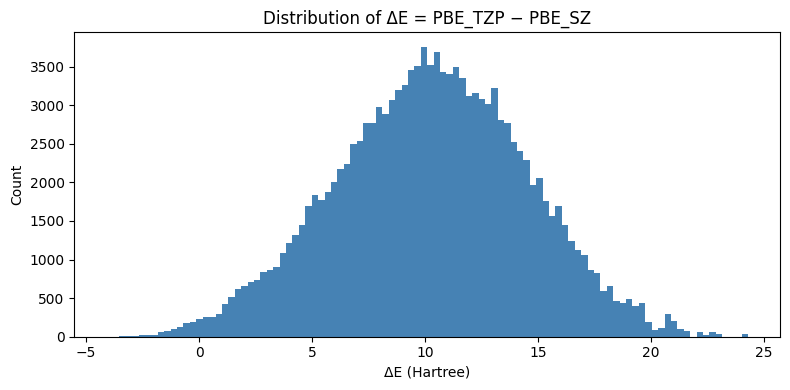

In [ ]:
# Plot distribution of ΔE values across all 133k molecules
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(delta_E, bins=100, color='steelblue', edgecolor='none')

ax.set_xlabel('ΔE (Hartree)')
ax.set_ylabel('Count')
ax.set_title('Distribution of ΔE = PBE_TZP − PBE_SZ')

plt.tight_layout()
plt.show()